In [1]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [2]:
drive.mount('/content/drive')
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/D100_Utility.py'
with open(utility_link) as f: exec(f.read())

Mounted at /content/drive


In [3]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [4]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [5]:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")

BlackJAX implementation data Loaded!


In [7]:
HighlightIndex = [1]
Warmup_List = [10, 20, 30, 40,50, 100, 200, 500, 1000]

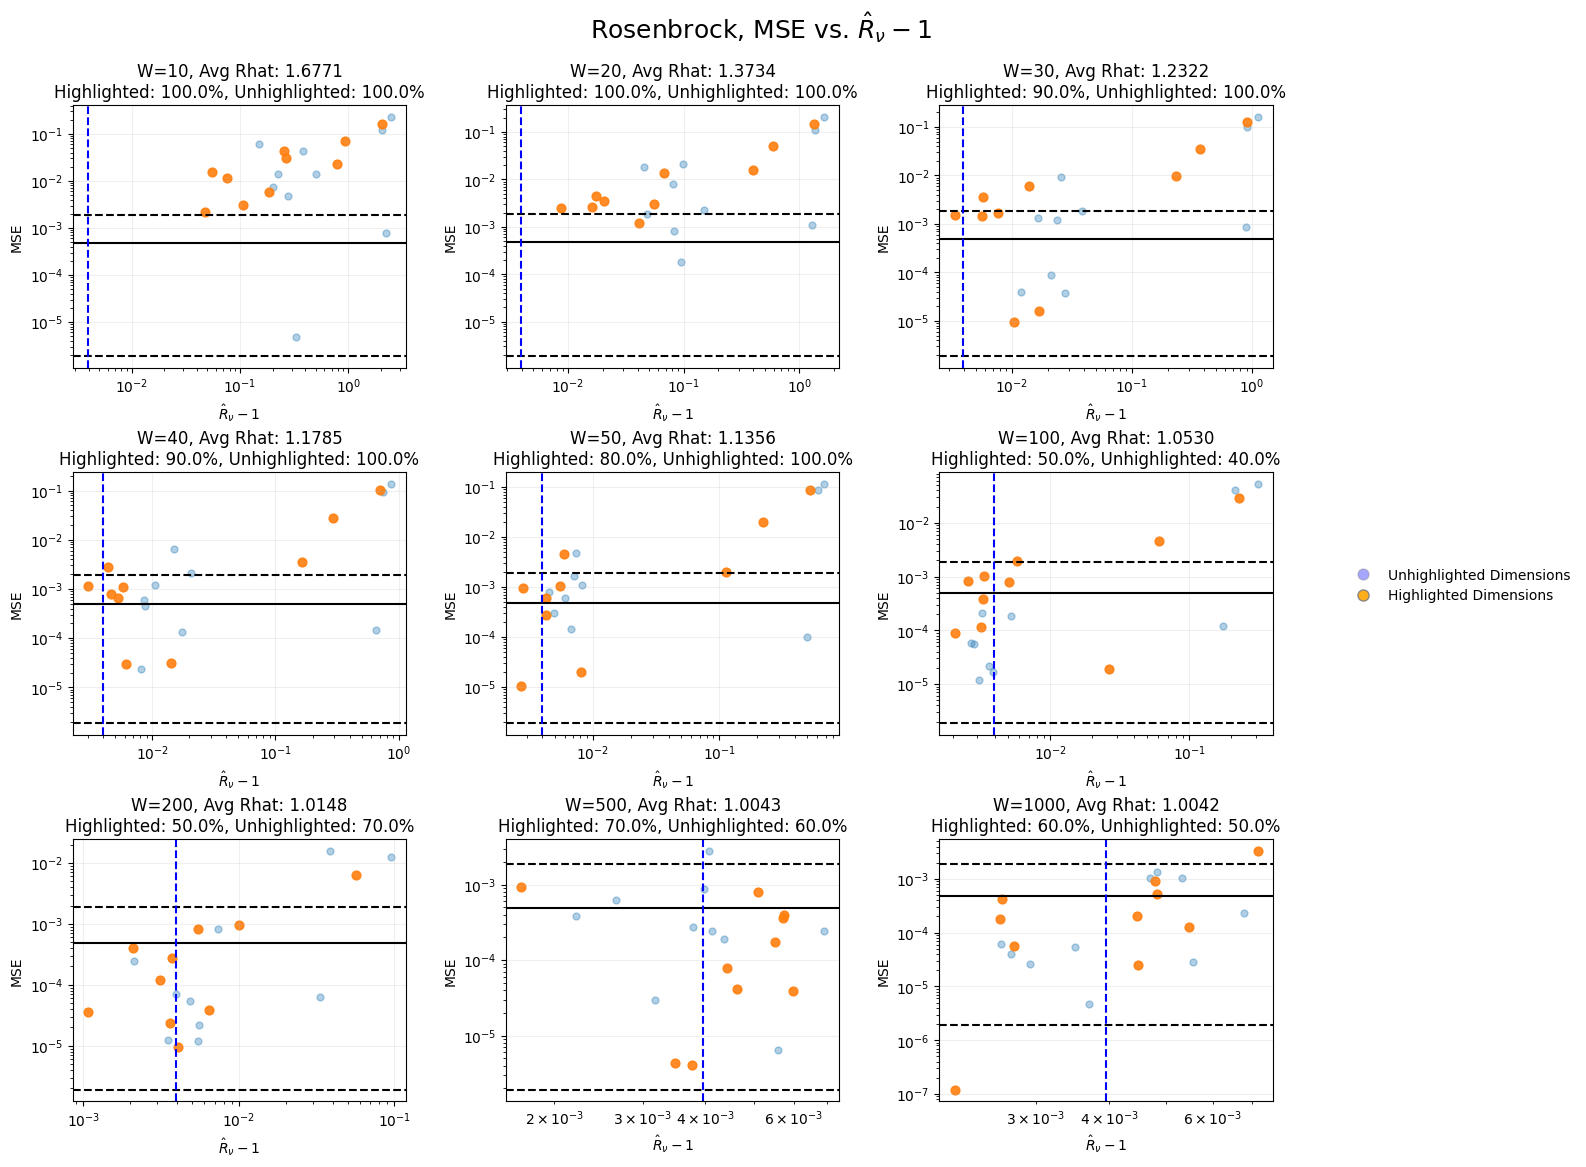

In [8]:
plot_mse_vs_rhat_9("Rosenbrock",
    bjx_R_Hat_c_df,
    Warmup_List,
    HighlightIndex,
    bound,
    threshold,
    num_chains_short)

In [9]:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")

TFP implementation data Loaded!


In [16]:
HighlightIndex = [0]
Warmup_List = [100, 200, 300, 400,500, 600, 700, 800, 1000]

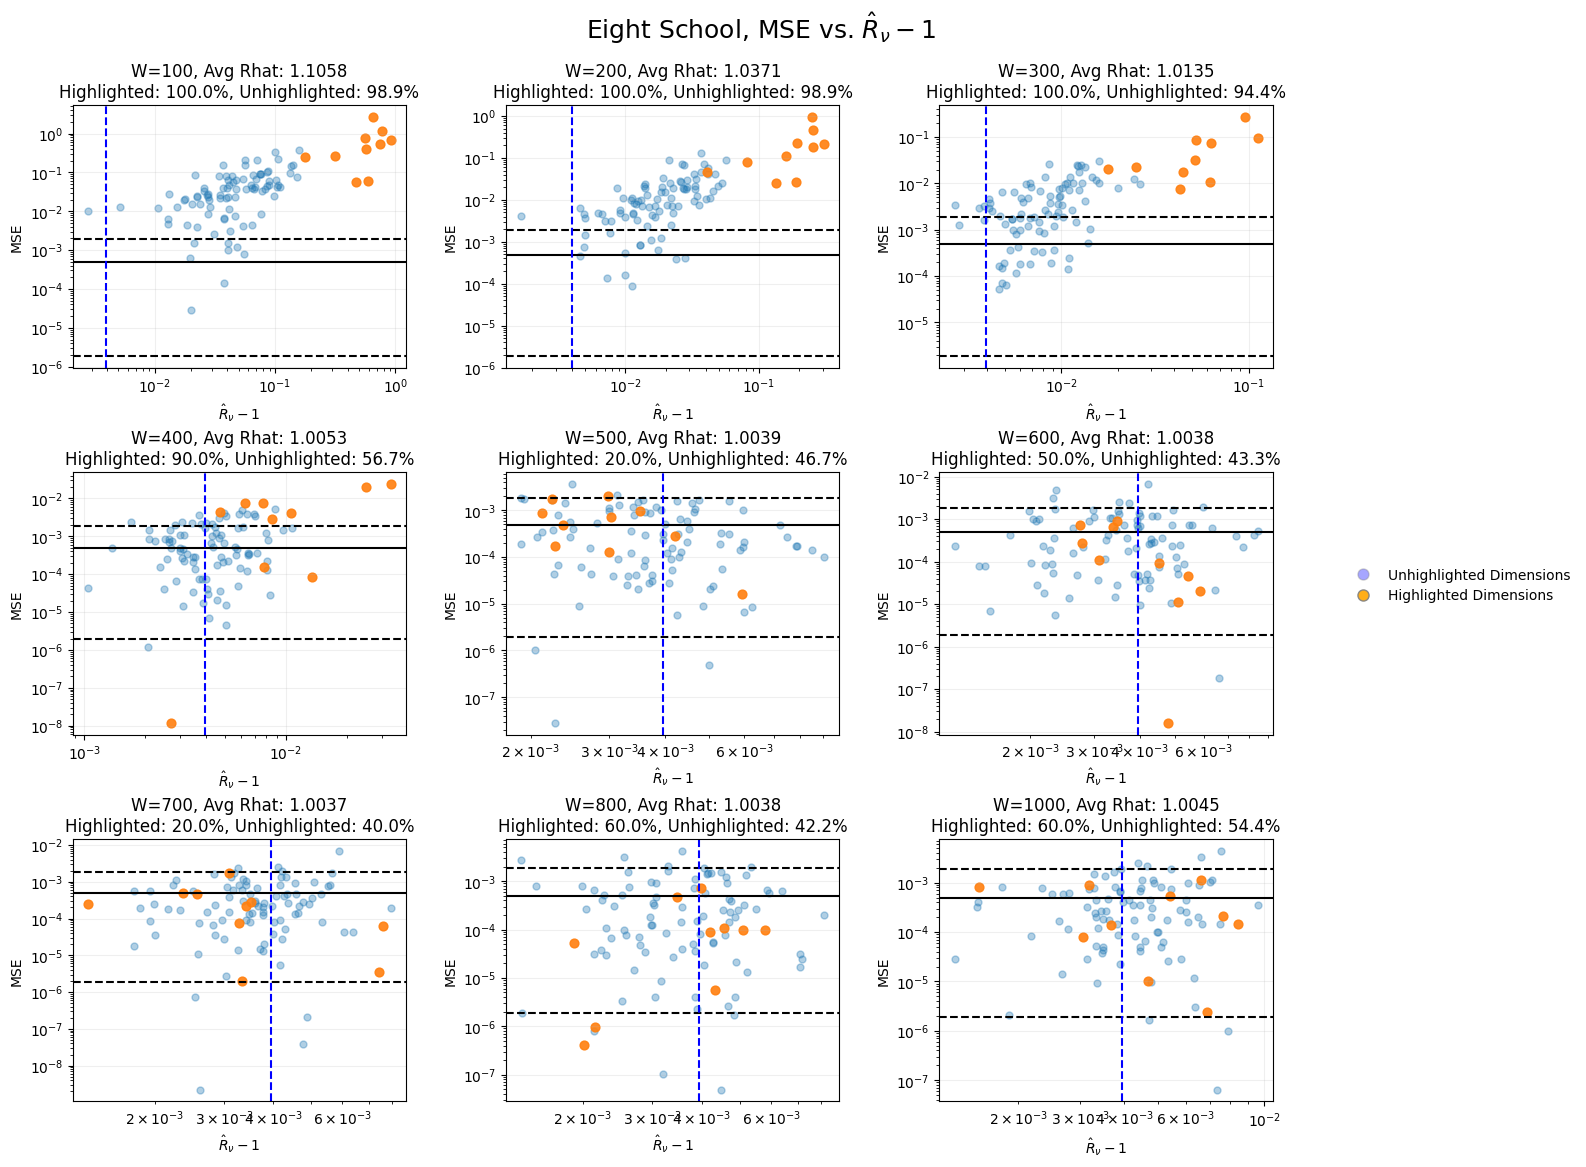

In [17]:
plot_mse_vs_rhat_9("Eight School",
    tfp_R_Hat_c_df,
    Warmup_List,
    HighlightIndex,
    bound,
    threshold,
    num_chains_short)

In [18]:
# n_high_variance = 10

# high_variance_indices = np.argsort(
#     np.asarray(var_benchmark)
# )[-n_high_variance:]

# print("High-variance dimensions:", high_variance_indices)
# print("Variances:", np.asarray(var_benchmark)[high_variance_indices])

# high_variance_indices

# done on PF numerical experiment

In [5]:
# IRT distribution
IRT_bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_constrained.pkl"
IRT_bjx_R_Hat_c_df = pd.read_pickle(IRT_bjx_R_hat_c_path)

IRT_bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_naive.pkl"
IRT_bjx_R_Hat_n_df = pd.read_pickle(IRT_bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")

BlackJAX implementation data Loaded!


In [6]:
HighlightIndex =  [179]
Warmup_List = [10, 20, 30, 40,50, 100, 200, 500, 1000]


# High-variance dimensions: [205 167 224 339 282 202   2 108  46 179]
# Variances: [0.11749712 0.1205561  0.12162668 0.12463009 0.12568337 0.12655112
#  0.13314247 0.13351665 0.13739026 0.14738768]
# array([205, 167, 224, 339, 282, 202,   2, 108,  46, 179])


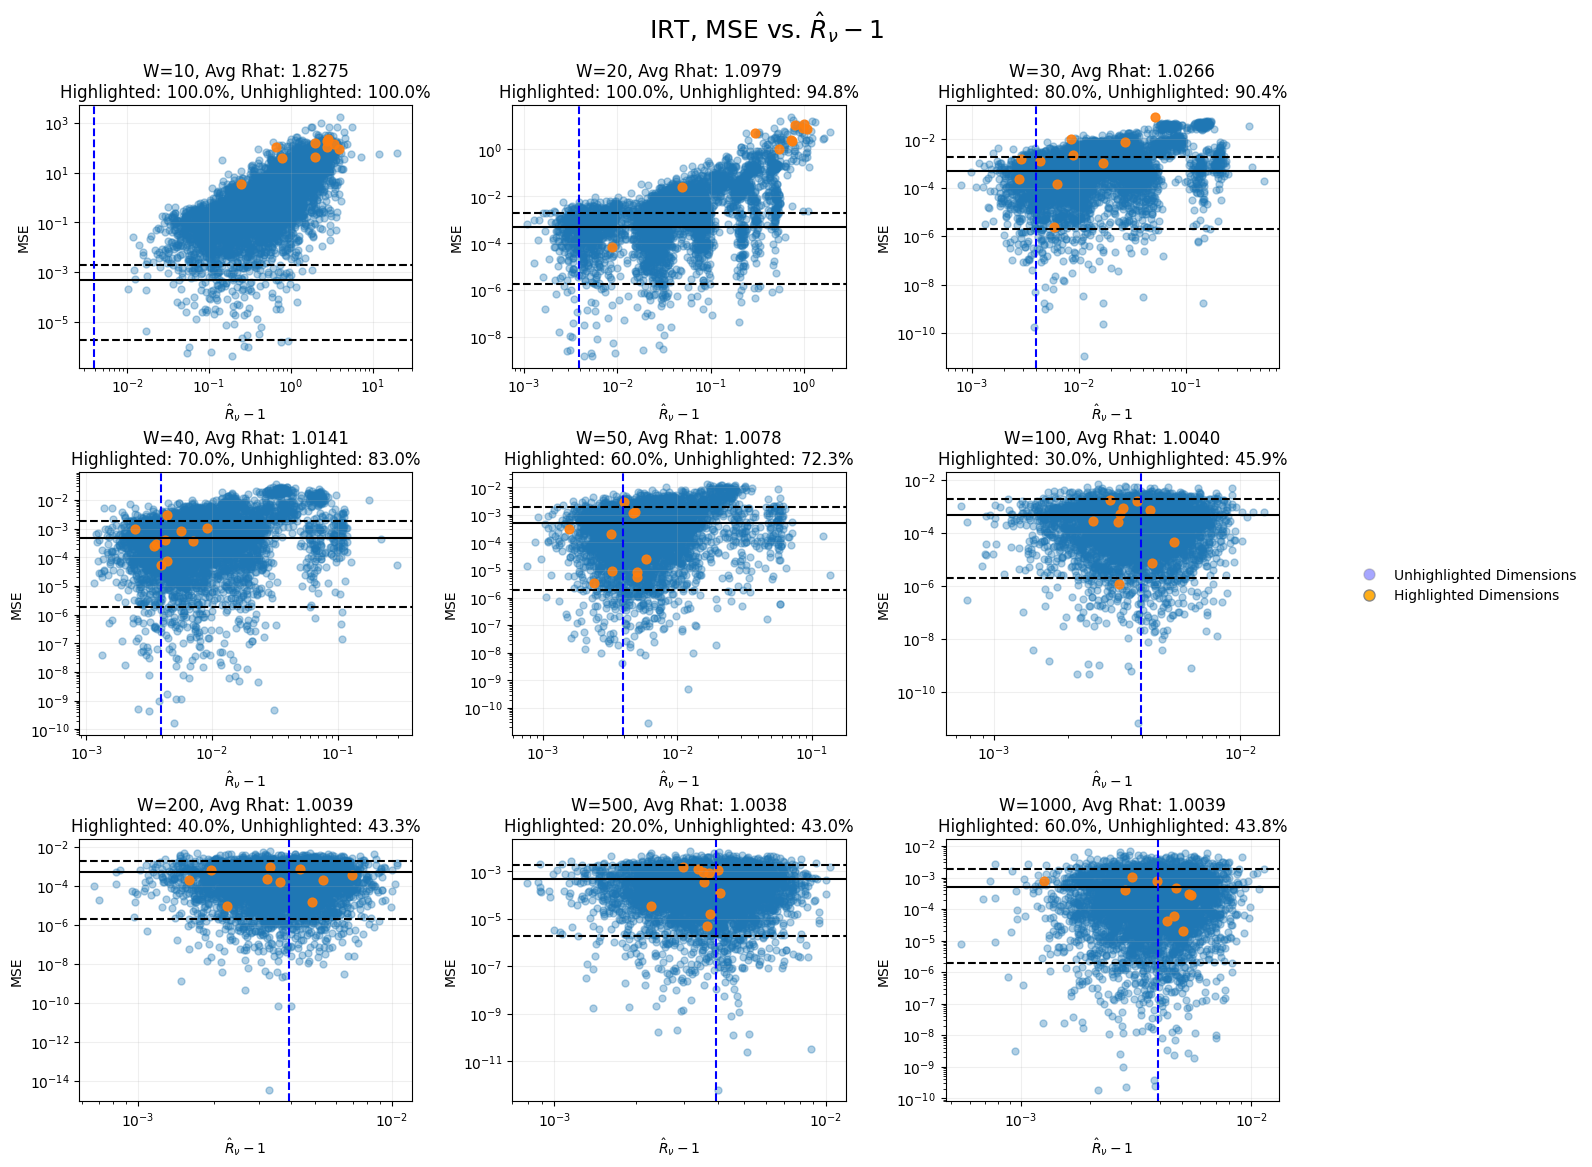

In [7]:
plot_mse_vs_rhat_9("IRT",
    IRT_bjx_R_Hat_c_df,
    Warmup_List,
    HighlightIndex,
    bound,
    threshold,
    num_chains_short)